# CEE6501 — Lecture 12.2

## Force Density Method

## Learning Objectives

By the end of this lecture, you will be able to:

- explain the role of the force density method within a broader framework of form-finding methods
- define the branch-node matrix and interpret how it describes network connectivity and branch projections
- derive the linear equilibrium equations of the force density method from nodal equilibrium and force density definitions
- construct the matrices $\mathbf{D} = \mathbf{C}^{T}\mathbf{Q}\mathbf{C}$ and $\mathbf{D}_f = \mathbf{C}^{T}\mathbf{Q}\mathbf{C}_f$
- solve for unknown free-node coordinates and recover the corresponding geometry, branch lengths, and branch forces

## Agenda

- Part 1 - A Single Framework for Form-Finding Methods
- Part 2 - Intro to Force Density
- Part 3 - Branch-Node Matrix Formulation
- Part 4 - Derivation of the Force Density Method
- Part 5 - Simple 2D Example
- Part 6 - New Equilibrium Shapes from Changing the Force Density
- Part 7 - 3D Example (Next Lecture)


## Part 1 - A Single Framework for Form-Finding Methods

### High-Level Motivation

In many **form-active structures**, the final geometry is not known in advance.

Instead, the shape must be found as part of the analysis, because **geometry and internal force depend on one another**.

This is the central idea behind **form finding**.


### References For This Part Of The Lecture

For this introductory discussion, we will draw mainly on two papers by Veenendaal and Block.

1. A conference paper published in 2011 at the IASS conference: *A Framework for Comparing Form Finding Methods*

2. A more developed journal paper published in 2012 in the International Journal of Solids and Structures: *An overview and comparison of structural form ﬁnding methods for general networks*

The journal paper is more comprehensive, but for today's lecture the conference paper is a very good starting point.

Links to both papers are posted on GitHub and saved in the Lecture 12 folder.

<div style="text-align:center;">
  <img src="assets/L2_ReferencePaper.png" style="width:90%;">
</div>

### Historical Context

Veenendaal and Block begin by placing form finding in a broader historical context.

By the 1960s and 1970s, computational form-finding had become important for lightweight spanning systems such as:

- cable-net roofs
- membrane roofs
- pneumatic structures
- gridshells

As these structural systems developed, several different numerical strategies also emerged for finding equilibrium shapes.

### Three Main Families Of Methods

Veenendaal and Block group classical form-finding methods into three main families:

- **Force density methods**
- **Dynamic relaxation methods**
- **Stiffness methods**

These methods are often presented separately, but they are all trying to solve the same basic problem:

- describe a structural network
- satisfy equilibrium
- determine the corresponding geometry

<div style="text-align:center;">
  <img src="assets/L2_ReferencePaper_Timeline.png" style="width:99%;">
</div>

### Types Of Structural Systems

These methods are applied to:

- **Bar-and-joint frameworks**: axial elements connected at nodes
- **Triangulated surface or shell meshes**: planar elements connected through nodes

In this course, we will focus only on the simpler **bar-and-joint case**.

That includes structures such as:

- trusses
- cable nets
- simple space-frame type networks


### What Distinguishes These Methods

**Force density methods** use the ratio of force to length as the central quantity.

**Dynamic relaxation methods** use an analogy with motion, where residual forces are converted into nodal accelerations and the structure iteratively moves toward equilibrium.

**Stiffness methods** use structural stiffness directly, so the form is found by enforcing equilibrium with an explicit stiffness model.

### Why A Common Framework Is Useful

A key message of the Veenendaal and Block papers is that these methods are often **more similar than they first appear**.

What changes from one method to another is mainly:

- how internal forces are represented
- how the unknown geometry is updated
- what quantity is chosen as the primary variable

So rather than treating them as completely separate ideas, Veenendaal and Block show that they can be compared within a single mathematical viewpoint.



### A Preview Of The Unified Framework

These three method families can be written within a common iterative framework.

A representative expression is:

$$
\mathbf{x}_{i+1}
=
\mathbf{x}_i
+
\left(\mathbf{C}^{T}\mathbf{K}\mathbf{C}\right)^{-1}
\left(
\mathbf{p}
-
\mathbf{C}^{T}\mathbf{L}^{-1}\mathbf{F}\mathbf{C}_f\,\mathbf{x}_f
-
\mathbf{C}^{T}\mathbf{L}^{-1}\mathbf{F}\mathbf{C}\,\mathbf{x}_i
\right)
$$

At this stage, do **not** worry about every symbol.

The main idea is that all three methods can be viewed as the following process:

1. writing equilibrium on a network of nodes and branches (i.e., members or elements)
2. evaluating the current internal force state
2. updating the nodal coordinates toward equilibrium


### The Unified Framework Conceptually

$$
\mathbf{x}_{i+1}
=
\mathbf{x}_i
+
\left(\mathbf{C}^{T}\mathbf{K}\mathbf{C}\right)^{-1}
\underbrace{\left(
\mathbf{p}
-
\mathbf{C}^{T}\mathbf{L}^{-1}\mathbf{F}\mathbf{C}_f\,\mathbf{x}_f
-
\mathbf{C}^{T}\mathbf{L}^{-1}\mathbf{F}\mathbf{C}\,\mathbf{x}_i
\right)}_{\text{residual}}
$$

This looks like a standard iterative correction:

$$
\text{new coordinates}
=
\text{current coordinates}
+
\text{correction based on the residual}
$$

We will return later to the meaning and usage of the full equation.

For now, the main takeaway is that the methods differ less in overall structure, and more in **how the internal branch quantities are defined**.

### Force Over Length Term

One important quantity that appears in the unified framework is

$$
\mathbf{L}^{-1}\mathbf{F}
$$

In matrix notation, we do not write this as a division. Instead, the operation is represented by multiplying the force vector by the inverse of the diagonal length matrix.

For a single branch, this corresponds to the scalar quantity

$$
l_i^{-1} f_i
=
\frac{f_i}{l_i}
$$



### Importance of the Force Over Length Term 

This ratio matters because, in axial networks, the branch force is always tied to the **current geometry** through the branch length.

So if the shape changes, the lengths change, and therefore the relation between force and geometry changes as well.

That is exactly why form finding is difficult in the first place: **equilibrium depends on geometry, and geometry affects the branch force state**.

The quantity force-over-length is important because it captures that branch force state in a form that works naturally with the network equations.

### Transition To Force Density

Among the three method families, the **force density method** is especially attractive because it leads to a particularly clean mathematical formulation that leads to a linear solution.

Its central idea is to use, for each branch,

$$
q_i = \frac{f_i}{l_i}
$$

as the primary analysis parameter.

The quantity $q_i$ is called the **force density** of branch $i$.

So before returning later to the broader unified framework, we first need to understand the **force density method on its own terms**, beginning with Schek's original formulation

## Part 2 - Intro to Force Density

> Schek, *The Force Density Method for Form Finding and Computation of General Networks* (1973)

### The Basic Problem

Schek starts from a very direct question:

Given a **pin-jointed network** of cables or bars, what equilibrium shapes can that network take under given supports and loading?


### Geometry is Unknown

At the start, the **connectivity** of the network is known, but the **final geometry is not**.

So the task is not simply to analyze a structure of known shape.

The task is to **find the shape itself**.

The essential requirement is that the final configuration must satisfy **equilibrium**, meaning that the sum of forces must be zero at every node.

### Why Form Matters

For long-span and lightweight structures, the structural form has a major influence on:

- the internal forces
- the deformations
- the overall structural behavior

In many cases, equilibrium final forms are not available in advance.

So form finding becomes a necessary step before more detailed structural analysis can even begin.

### Network View Of The Structure

Schek models the structure as a **network of nodes and branches**.

- nodes are joints
- branches are axial members such as cables or bars
- the branches connect only through the nodes
- the geometry is allowed to change until an equilibrium shape is found

### Why A New Method Was Helpful

Earlier approaches often relied on:

- physical experiments
- trial-and-error procedures
- nonlinear iterative calculations with many steps

Those approaches could be useful, but they were not always efficient when exploring many possible shapes.

Schek's goal was to build a computational method that keeps the network description simple, while making the equilibrium calculation much more direct.

### The New Description Parameter

Schek's key idea is to describe each branch using the ratio of force to length:

$$
q_i = \frac{s_i}{l_i}
$$

where:

- $s_i$ = axial force in branch $i$ 
- $l_i$ = length of branch $i$
- $q_i$ = force density of branch $i$

So instead of prescribing the final shape directly, we prescribe one scalar quantity for each branch: its **force density**.

note: following Schek's notation in the paper, so $s_i = f_i$

### The Solution Becomes Linear

This choice is powerful because, when the force densities are treated as known, the equilibrium equations become **linear in the unknown nodal coordinates**.

That is one of the main reasons the method became so influential in form finding.

So the classical force density method works like this:

- the network connectivity is known
- the support locations are known
- the force densities are prescribed (set by the designer)
- the unknown node coordinates are solved from a linear system

This is the main practical advantage emphasized by Schek.

### Linear Form Finding Versus Nonlinear Constraints

Schek also makes an important qualification.

The linear force density formulation is very effective for finding an equilibrium shape, but it does **not** automatically enforce every other design requirement.

If we add further conditions, the problem may become nonlinear again.


### Examples of Added Nonlinearity

The Force Density method is linear in its basic form, but it can also be extended into a **nonlinear method** when extra constraints are imposed.

- geometric constraints
- prescribed mesh conditions
- additional force constraints
- other design restrictions beyond simple equilibrium



### Why The Linear Version Is Still Valuable

Even when additional constraints are needed later, the linear method is still extremely useful.

It gives:

- a fast first equilibrium shape
- a clean way to explore many different forms
- a good starting point for more detailed nonlinear calculations

So the linear force density method is both a useful form-finding tool on its own and a practical starting point for more advanced analysis.

### Notation And Diagonal Matrices

Schek uses a compact matrix notation throughout the paper.

The basic convention is:

- **lowercase letters** are vectors
- **uppercase letters** are matrices

A particularly important pattern is when the **same letter appears in both lowercase and uppercase**.

In that case, the uppercase version is usually the **diagonal matrix formed from the vector**.



For example, if

$$
\mathbf{q}^{T}
=
\begin{bmatrix}
q_1 & q_2 & \cdots & q_m
\end{bmatrix}
$$

then

$$
\mathbf{Q}
=
\begin{bmatrix}
q_1 & 0   & 0   & \cdots & 0 \\
0   & q_2 & 0   & \cdots & 0 \\
0   & 0   & q_3 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0   & 0   & 0   & \cdots & q_m
\end{bmatrix}
$$

Similarly:

- $\mathbf{l}$ becomes $\mathbf{L}$
- $\mathbf{s}$ becomes $\mathbf{S}$



### Setting up the Force Density Method

The next step is to describe the **connectivity of the network** using the **branch-node matrix** does.

It tells us which nodes each branch connects, and with what orientation.

Once that connectivity is written in matrix form, the branch quantities (i.e, force densities) and the nodal coordinates can be linked together in a very compact way.

So next, we move to the **branch-node matrix formulation**.

## Part 3 - Branch-Node Matrix Formulation

### Connectivity Comes First

In the direct stiffness method, we usually work at the **element level**:

- define local element behavior
- transform to global coordinates
- assemble into a global system

In the force density method, we shift viewpoint.

We work more directly at the **nodal level**:
- the **topology** becomes the most important parameter
- how nodes are connected by branches

The key object here is the **branch-node matrix**.

### Definition Of The Branch-Node Matrix

The branch-node matrix, $\mathbf{C}_s$, is an $m \times n$ matrix, where:

- $m$ = number of branches
- $n$ = number of nodes

So in general, it is **not square**.

More specifically, we write

$$
\mathbf{C}_s \in \mathbb{R}^{m \times n}
$$


Each **row** corresponds to one branch, and each **column** corresponds to one node.

For a branch $i$ connecting start node $j$ to end node $k$, the entries of the $i$-th row are

$$
C_s(i,r)=
\begin{cases}
+1 & \text{if } r=j \\
-1 & \text{if } r=k \\
0  & \text{otherwise}
\end{cases}
$$

So each row records:

- **which two nodes** the branch connects
- the **chosen orientation** of that branch

The orientation is just a bookkeeping convention, but it matters because it determines the sign of the branch coordinate differences.

### Example Of A Branch-Node Matrix
<div style="display:flex; gap:1.2rem; align-items:flex-start;">

  <div style="flex:0.38;">
    <figure style="margin:0; text-align:center; display:flex; flex-direction:column;">
      <img src="assets/L2_BranchNode.png" style="width:100%; height:auto;">
    </figure>
  </div>

  <div style="flex:0.62; font-size:0.60em; text-align:left; margin-top:0.5rem;">
  
  $$
  \mathbf{C}_s
  =
  \begin{bmatrix}
   1 &  0 &  0 &  0 &  0 & -1 &  0 &  0 &  0 \\
   0 &  1 &  0 &  0 &  0 &  0 & -1 &  0 &  0 \\
   0 &  0 &  1 &  0 &  0 &  0 &  0 & -1 &  0 \\
   0 &  0 &  0 &  1 &  0 &  0 &  0 &  0 & -1 \\
   1 &  0 &  0 & -1 &  0 &  0 &  0 &  0 &  0 \\
   1 & -1 &  0 &  0 &  0 &  0 &  0 &  0 &  0 \\
   0 &  1 & -1 &  0 &  0 &  0 &  0 &  0 &  0 \\
   0 &  0 &  1 & -1 &  0 &  0 &  0 &  0 &  0 \\
   0 &  0 &  0 &  1 & -1 &  0 &  0 &  0 &  0 \\
   1 &  0 &  0 &  0 & -1 &  0 &  0 &  0 &  0 \\
   0 &  1 &  0 &  0 & -1 &  0 &  0 &  0 &  0 \\
   0 &  0 &  1 &  0 & -1 &  0 &  0 &  0 &  0
  \end{bmatrix}
  $$
  
  </div>

</div>

### Example Of A Branch-Node Matrix
<div style="display:flex; gap:1.2rem; align-items:flex-start;">

  <div style="flex:0.38;">
    <figure style="margin:0; text-align:center; display:flex; flex-direction:column;">
      <img src="assets/L2_BranchNode1.png" style="width:100%; height:auto;">
    </figure>
  </div>

  <div style="flex:0.62; font-size:0.60em; text-align:left; margin-top:0.5rem;">
  
  $$
  \mathbf{C}_s
  =
  \begin{bmatrix}
   1 &  0 &  0 &  0 &  0 & -1 &  0 &  0 &  0 \\
   0 &  1 &  0 &  0 &  0 &  0 & -1 &  0 &  0 \\
   0 &  0 &  \boxed{1} &  0 &  0 &  0 &  0 & \boxed{-1} &  0 \\
   0 &  0 &  0 &  1 &  0 &  0 &  0 &  0 & -1 \\
   1 &  0 &  0 & -1 &  0 &  0 &  0 &  0 &  0 \\
   1 & -1 &  0 &  0 &  0 &  0 &  0 &  0 &  0 \\
   0 &  1 & -1 &  0 &  0 &  0 &  0 &  0 &  0 \\
   0 &  0 &  1 & -1 &  0 &  0 &  0 &  0 &  0 \\
   0 &  0 &  0 &  1 & -1 &  0 &  0 &  0 &  0 \\
   1 &  0 &  0 &  0 & -1 &  0 &  0 &  0 &  0 \\
   0 &  1 &  0 &  0 & -1 &  0 &  0 &  0 &  0 \\
   0 &  0 &  1 &  0 & -1 &  0 &  0 &  0 &  0
  \end{bmatrix}
  $$
  
  </div>

</div>

### Example Of A Branch-Node Matrix
<div style="display:flex; gap:1.2rem; align-items:flex-start;">

  <div style="flex:0.38;">
    <figure style="margin:0; text-align:center; display:flex; flex-direction:column;">
      <img src="assets/L2_BranchNode2.png" style="width:100%; height:auto;">
    </figure>
  </div>

  <div style="flex:0.62; font-size:0.60em; text-align:left; margin-top:0.5rem;">
  
  $$
  \mathbf{C}_s
  =
  \begin{bmatrix}
   1 &  0 &  0 &  0 &  0 & -1 &  0 &  0 &  0 \\
   0 &  1 &  0 &  0 &  0 &  0 & -1 &  0 &  0 \\
   0 &  0 &  1 &  0 &  0 &  0 &  0 & -1 &  0 \\
   0 &  0 &  0 &  1 &  0 &  0 &  0 &  0 & -1 \\
   1 &  0 &  0 & -1 &  0 &  0 &  0 &  0 &  0 \\
   1 & -1 &  0 &  0 &  0 &  0 &  0 &  0 &  0 \\
   0 &  1 & -1 &  0 &  0 &  0 &  0 &  0 &  0 \\
   0 &  0 &  1 & -1 &  0 &  0 &  0 &  0 &  0 \\
   0 &  0 &  0 &  1 & -1 &  0 &  0 &  0 &  0 \\
   1 &  0 &  0 &  0 & -1 &  0 &  0 &  0 &  0 \\
   0 &  \boxed{1} &  0 &  0 & \boxed{-1} &  0 &  0 &  0 &  0 \\
   0 &  0 &  1 &  0 & -1 &  0 &  0 &  0 &  0
  \end{bmatrix}
  $$
  
  </div>

</div>

### Why The Branch-Node Matrix Is Useful

The branch-node matrix is useful because it gives us a compact way to represent the **connectivity of the network** inside the algebra.

Once the connectivity is written in matrix form, we no longer have to describe each branch-node relation one at a time.

Instead, the full network can be handled through matrix operations.



This is powerful because the same matrix can then be used to:

- encode which nodes each branch connects
- keep track of branch orientation through sign
- move between **nodal quantities** and **branch-wise quantities**
- assemble branch contributions back into nodal equilibrium equations

So the branch-node matrix is more than just a definition of connectivity.

It is the main matrix tool that lets the topology of the network participate directly in the formulation.

### Branch Coordinate Differences

Using the branch-node matrix we can easily calculate coordinate differences between nodal pairs

If $\mathbf{x}$ is the vector of all nodal $x$-coordinates, then the branch coordinate differences (i.e., for each member) in the $x$-direction are

$$
\mathbf{u} = \mathbf{C}\mathbf{x}
$$

which is analogous to doing $\Delta_x = x_{start} - x_{end}$ for each node pair defining each branch

Likewise, in the $y$- and $z$-directions,

$$
\mathbf{v} = \mathbf{C}\mathbf{y}
$$

$$
\mathbf{w} = \mathbf{C}\mathbf{z}
$$

### Partition into Free And Fixed Nodes

You can further partitions the nodes into:

- **free nodes** with unknown coordinates
- **fixed nodes** with prescribed coordinates

Accordingly, the full branch-node matrix is partitioned as

$$
\mathbf{C}_s = \left[ \mathbf{C} \;\; \mathbf{C}_f \right]
$$

where:

- $\mathbf{C}$ acts on the unknown free-node coordinates
- $\mathbf{C}_f$ acts on the known fixed-node coordinates

### Partitioned Branch-Node Matrix
<div style="display:flex; gap:1.2rem; align-items:flex-start;">

  <div style="flex:0.38;">
    <figure style="margin:0; text-align:center; display:flex; flex-direction:column;">
      <img src="assets/L2_BranchNode_fixed.png" style="width:100%; height:auto;">
    </figure>
  </div>

  <div style="flex:0.62; font-size:0.60em; text-align:left; margin-top:0.5rem;">
  
$$
\mathbf{C}_s
=
\left[\mathbf{C}\;\middle|\;\mathbf{C}_f\right]
=
\left[
\begin{array}{ccccc:cccc}
 1 &  0 &  0 &  0 &  0 & -1 &  0 &  0 &  0 \\
 0 &  1 &  0 &  0 &  0 &  0 & -1 &  0 &  0 \\
 0 &  0 &  1 &  0 &  0 &  0 &  0 & -1 &  0 \\
 0 &  0 &  0 &  1 &  0 &  0 &  0 &  0 & -1 \\
 1 &  0 &  0 & -1 &  0 &  0 &  0 &  0 &  0 \\
 1 & -1 &  0 &  0 &  0 &  0 &  0 &  0 &  0 \\
 0 &  1 & -1 &  0 &  0 &  0 &  0 &  0 &  0 \\
 0 &  0 &  1 & -1 &  0 &  0 &  0 &  0 &  0 \\
 0 &  0 &  0 &  1 & -1 &  0 &  0 &  0 &  0 \\
 1 &  0 &  0 &  0 & -1 &  0 &  0 &  0 &  0 \\
 0 &  1 &  0 &  0 & -1 &  0 &  0 &  0 &  0 \\
 0 &  0 &  1 &  0 & -1 &  0 &  0 &  0 &  0
\end{array}
\right]
$$

### Branch Coordinate Differences (Partitioned)

If $\mathbf{x}$ is the vector of unknown free-node $x$-coordinates and $\mathbf{x}_f$ is the vector of fixed-node $x$-coordinates, then the branch coordinate differences in the $x$-direction are

$$
\mathbf{u} = \mathbf{C}\mathbf{x} + \mathbf{C}_f\mathbf{x}_f
$$


$$
\underbrace{\mathbf{u}}_{m \times 1}
=
\underbrace{\mathbf{C}}_{m \times n_f}
\underbrace{\mathbf{x}}_{n_f \times 1}
+
\underbrace{\mathbf{C}_f}_{m \times n_r}
\underbrace{\mathbf{x}_f}_{n_r \times 1}
$$

Likewise, in the $y$- and $z$-directions,

$$
\mathbf{v} = \mathbf{C}\mathbf{y} + \mathbf{C}_f\mathbf{y}_f
$$

$$
\mathbf{w} = \mathbf{C}\mathbf{z} + \mathbf{C}_f\mathbf{z}_f
$$

So these vectors contain, branch-by-branch, the signed coordinate differences that define each element in each direction.

### Example Structure

<div style="display:flex; gap:1.2rem; align-items:flex-start;">

  <div style="flex:0.50;">
    <figure style="margin:0; text-align:center; display:flex; flex-direction:column;">
      <img src="assets/L2_BranchNode_Example.png" style="width:100%; height:auto;">
    </figure>
  </div>

  <div style="flex:0.50; font-size:0.60em; text-align:left; margin-top:0.3rem;">

  The nodal coordinate matrix is

  $$
  \mathrm{nodes}
  =
  \left\{
  \begin{aligned}
  1 &: (0,0)\\
  2 &: (1,3)\\
  3 &: (3,0)\\
  4 &: (5,4)
  \end{aligned}
  \right.
  $$

  The nodal load matrix is

  $$
  \mathrm{nodes\_loads}
  =
  \left\{
  \begin{aligned}
  1 &: (-10,-10)\\
  2 &: (0,0)\\
  3 &: (0,0)\\
  4 &: (0,0)
  \end{aligned}
  \right.
  $$

  The element connectivity is

  $$
  \mathrm{elements}
  =
  \left\{
  \begin{aligned}
  1 &: (1,3)\\
  2 &: (1,2)\\
  3 &: (2,3)\\
  4 &: (2,4)\\
  5 &: (3,4)
  \end{aligned}
  \right.
  $$

  </div>

</div>

In [1]:
nodes = {
    1: (0.0, 0.0),
    2: (1.0, 3.0),
    3: (3.0, 0.0),
    4: (5.0, 4.0),
}
nodes_loads = {
    1: (-10.0, -10.0),
    2: (0.0, 0.0),
    3: (0.0, 0.0),
    4: (0.0, 0.0),
}
# Branches defined by their start and end nodes (1-indexed)
elements = {
    1: (1, 3),
    2: (1, 2),
    3: (2, 3),
    4: (2, 4),
    5: (3, 4),
}
fixed_nodes = [3, 4] #1-indexed
free_nodes = [1, 2] #1-indexed

### Example Calculation Of Branch Projections
<div style="display:flex; gap:1.2rem; align-items:flex-start;">

  <div style="flex:0.50;">
    <figure style="margin:0; text-align:center; display:flex; flex-direction:column;">
      <img src="assets/L2_BranchNode_Example.png" style="width:100%; height:auto;">
    </figure>
  </div>

  <div style="flex:0.50; font-size:0.60em; text-align:left; margin-top:0.3rem;">

$$
\mathbf{C}
=
\begin{bmatrix}
1 & 0 & -1 & 0 \\
1 & -1 & 0 & 0 \\
0 & 1 & -1 & 0 \\
0 & 1 & 0 & -1 \\
0 & 0 & 1 & -1 
\end{bmatrix}
$$

$$
\mathbf{x}^{T}
=
\begin{bmatrix}
0 & 1 & 3 & 5
\end{bmatrix}
\qquad
\mathbf{y}^{T}
=
\begin{bmatrix}
0 & 3 & 0 & 4
\end{bmatrix}
$$

$$
\mathbf{C}\mathbf{x}
=
\begin{bmatrix}
(1)(0) + (0)(1) + (-1)(3) + (0)(5) \\
(1)(0) + (-1)(1) + (0)(3) + (0)(5) \\
(0)(0) + (1)(1) + (-1)(3) + (0)(5) \\
(0)(0) + (1)(1) + (0)(3) + (-1)(5) \\
(0)(0) + (0)(1) + (1)(3) + (-1)(5)
\end{bmatrix}
=
\begin{bmatrix}
-3 \\
-1 \\
-2 \\
-4 \\
-2
\end{bmatrix}
$$

  </div>

</div>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

In [3]:
# ------------------------------------------------------------
# Build branch-node matrix
# ------------------------------------------------------------
def build_full_branch_node_matrix(elements):
    n_nodes = max(max(start, end) for start, end in elements.values())
    m = len(elements)

    C_s = np.zeros((m, n_nodes), dtype=int)

    for r, (start, end) in enumerate(elements.values()):
        C_s[r, start - 1] = 1
        C_s[r, end - 1] = -1

    return C_s

C_s = build_full_branch_node_matrix(elements)
print(C_s)

[[ 1  0 -1  0]
 [ 1 -1  0  0]
 [ 0  1 -1  0]
 [ 0  1  0 -1]
 [ 0  0  1 -1]]


In [4]:
# ------------------------------------------------------------
# Build partitioned branch-node matrices
# ------------------------------------------------------------
def partition_branch_node_matrix(C_s, free_nodes):
    free_idx = [node - 1 for node in free_nodes]
    fixed_idx = [j for j in range(C_s.shape[1]) if j not in free_idx]

    C = C_s[:, free_idx]
    C_f = C_s[:, fixed_idx]

    return C, C_f

C, C_f = partition_branch_node_matrix(C_s, free_nodes)
print(C)
print(C_f)

[[ 1  0]
 [ 1 -1]
 [ 0  1]
 [ 0  1]
 [ 0  0]]
[[-1  0]
 [ 0  0]
 [-1  0]
 [ 0 -1]
 [ 1 -1]]


In [5]:
# ------------------------------------------------------------
# Coordinate vectors
# ------------------------------------------------------------
def build_coordinate_vectors(nodes, free_nodes, fixed_nodes):
    x = np.array([nodes[node][0] for node in free_nodes], dtype=float).reshape(-1, 1)
    y = np.array([nodes[node][1] for node in free_nodes], dtype=float).reshape(-1, 1)
    x_f = np.array([nodes[node][0] for node in fixed_nodes], dtype=float).reshape(-1, 1)
    y_f = np.array([nodes[node][1] for node in fixed_nodes], dtype=float).reshape(-1, 1)
    return x, y, x_f, y_f

x, y, x_f, y_f = build_coordinate_vectors(nodes, free_nodes, fixed_nodes)
print(x)
print(x_f)


[[0.]
 [1.]]
[[3.]
 [5.]]


In [6]:
# ------------------------------------------------------------
# Branch coordinate differences
# ------------------------------------------------------------
def build_branch_coordinate_differences(C, C_f, x, y, x_f, y_f):
    u = C @ x + C_f @ x_f
    v = C @ y + C_f @ y_f

    return u, v

u, v = build_branch_coordinate_differences(C, C_f, x, y, x_f, y_f)
print("\nu = Δx =\n", u)
print("\nv = Δy =\n", v)


u = Δx =
 [[-3.]
 [-1.]
 [-2.]
 [-4.]
 [-2.]]

v = Δy =
 [[ 0.]
 [-3.]
 [ 3.]
 [-1.]
 [-4.]]


In [7]:
# ------------------------------------------------------------
# Branch lengths
# ------------------------------------------------------------
l = np.sqrt(u**2 + v**2)
print("\nl = √(Δx² + Δy²) =\n", l)


l = √(Δx² + Δy²) =
 [[3.    ]
 [3.1623]
 [3.6056]
 [4.1231]
 [4.4721]]


### Transition To The Derivation

Now that we have a matrix description of the network connectivity, we have the missing ingredient needed to write equilibrium in compact form.

The next step is to combine:

- the branch-node matrix
- the branch projections
- the force densities

to derive the governing equilibrium equations of the force density method.

So next, we move from **network description** to the **actual derivation of the method**.

## Part 4 - Derivation of the Force Density Method

### Setup

We model the structure as a set of branches connecting free and fixed nodes in 3D space.

Free nodes:

$$
P_i = (x_i, y_i, z_i), \qquad i = 1, 2, \dots, n
$$

Fixed nodes:

$$
P_{f,i} = (x_{f,i}, y_{f,i}, z_{f,i}), \qquad i = 1, 2, \dots, n_f
$$

Coordinate vectors:

$$
\mathbf{x},\mathbf{y},\mathbf{z} \in \mathbb{R}^{n},
\qquad
\mathbf{x}_f,\mathbf{y}_f,\mathbf{z}_f \in \mathbb{R}^{n_f}
$$

Branch quantities:

$$
\mathbf{l} =
\begin{bmatrix}
l_1 & l_2 & \cdots & l_m
\end{bmatrix}^{T},
\qquad
\mathbf{s} =
\begin{bmatrix}
s_1 & s_2 & \cdots & s_m
\end{bmatrix}^{T}
$$

External nodal loads:

$$
\mathbf{p}_x,\mathbf{p}_y,\mathbf{p}_z \in \mathbb{R}^{n}
$$

where node $i$ has load components $p_{x,i}$, $p_{y,i}$, and $p_{z,i}$.

### Step 1 - define branch projections and branch lengths

For each branch, define its projected differences in the coordinate directions:

$$
\mathbf{u} = \mathbf{C}\mathbf{x} + \mathbf{C}_f\mathbf{x}_f
$$

$$
\mathbf{v} = \mathbf{C}\mathbf{y} + \mathbf{C}_f\mathbf{y}_f
$$

$$
\mathbf{w} = \mathbf{C}\mathbf{z} + \mathbf{C}_f\mathbf{z}_f
$$

For a planar problem, we usually only need $\mathbf{u}$ and $\mathbf{v}$.

The branch lengths are collected in the vector

$$
\mathbf{l}
=
\begin{bmatrix}
l_1 & l_2 & \cdots & l_m
\end{bmatrix}^{T}
$$

with

$$
l_i = \sqrt{u_i^2 + v_i^2 + w_i^2}
$$

Schek then introduces diagonal matrices built from these vectors, such as $\mathbf{U}$, $\mathbf{V}$, $\mathbf{W}$, and $\mathbf{L}$

### Step 2 - Writing nodal equilibrium using branch forces

Let $s_i$ denote the axial force in branch $i$.

If we collect all branch forces into the vector $\mathbf{s}$, then nodal equilibrium in each coordinate direction can be written by balancing the internal branch-force contributions against the applied nodal loads:

$$
\mathbf{C}^{T}\mathbf{U}\mathbf{L}^{-1}\mathbf{s} = \mathbf{p}_x
\tag{1-1}
$$

$$
\mathbf{C}^{T}\mathbf{V}\mathbf{L}^{-1}\mathbf{s} = \mathbf{p}_y
\tag{1-2}
$$

$$
\mathbf{C}^{T}\mathbf{W}\mathbf{L}^{-1}\mathbf{s} = \mathbf{p}_z
\tag{1-3}
$$

1. The vectors $\mathbf{U}\mathbf{L}^{-1}\mathbf{s}$, $\mathbf{V}\mathbf{L}^{-1}\mathbf{s}$, and $\mathbf{W}\mathbf{L}^{-1}\mathbf{s}$ represent the branch-force components in the $x$-, $y$-, and $z$-directions.

2. The connectivity matrix $\mathbf{C}^{T}$ then gathers and sums those branch contributions at the free nodes.



To interpret this expression, first focus on

$$
\mathbf{U}\mathbf{L}^{-1}\mathbf{s}
$$

This gives the $x$-component of the internal force in each branch.

For a single member, this is just trigonometry: the axial force is resolved into its Cartesian components using the branch direction cosines.

<div style="text-align:center;">
  <img src="assets/L2_ForceDensity_Derive1.png" style="width:50%;">
</div>

$$
s_x = \frac{\Delta x}{L}s
$$

Next, the matrix $\mathbf{C}^{T}$ collects those branch-force components and sums the contributions acting at each free node.

Recall the connectivity matrix from the earlier example:

$$
\mathbf{C} =
\begin{bmatrix}
1 & 0 \\
1 & -1 \\
0 & 1 \\
0 & 1 \\
0 & 0
\end{bmatrix}
$$

Its transpose is

$$
\mathbf{C}^{T} =
\begin{bmatrix}
1 & 1 & 0 & 0 & 0 \\
0 & -1 & 1 & 1 & 0
\end{bmatrix}
$$

So in the product $\mathbf{C}^{T}\mathbf{U}\mathbf{L}^{-1}\mathbf{s}$, the first row of $\mathbf{C}^{T}$ gathers the branch contributions associated with free node 1, while the second row gathers the contributions associated with free node 2.



For this example:

- the first row involves members 1 and 2
- the second row involves members 2, 3, and 4

Thus, the result is a $2 \times 1$ vector whose entries are the summed internal-force components at the two free nodes.

<div style="text-align:center;">
  <img src="assets/L2_ForceDensity_Derive2.png" style="width:40%;">
</div>

$$
\mathbf{C}^{T} =
\begin{bmatrix}
1 & 1 & 0 & 0 & 0 \\
0 & -1 & 1 & 1 & 0
\end{bmatrix}
$$

### Step 3 - Define Force Density

The equilibrium form in Step 2 is correct, but it is still not especially convenient because the branch lengths are unknown and appear nonlinearly.

So the next step is the key simplification.

Define the force density vector by

$$
\mathbf{q} = \mathbf{L}^{-1}\mathbf{s}
$$

or componentwise,

$$
q_i = \frac{s_i}{l_i}
$$

substitute into Eq. 1

$$
\mathbf{C}^{T}\mathbf{U}\mathbf{q} = \mathbf{p}_x
\tag{2-1}
$$

$$
\mathbf{C}^{T}\mathbf{V}\mathbf{q} = \mathbf{p}_y
\tag{2-2}
$$

$$
\mathbf{C}^{T}\mathbf{W}\mathbf{q}= \mathbf{p}_z
\tag{2-3}
$$




Now use the matrix identities

$$
\mathbf{U}\mathbf{q} = \mathbf{Q}\mathbf{u},
\qquad
\mathbf{V}\mathbf{q} = \mathbf{Q}\mathbf{v},
\qquad
\mathbf{W}\mathbf{q} = \mathbf{Q}\mathbf{w}
$$

where

$$
\mathbf{Q} = \operatorname{diag}(q_1, q_2, \dots, q_m)
$$

For example:

$$
\mathbf{U}\mathbf{q}
=
\begin{bmatrix}
u_1 &        &        \\
    & \ddots &        \\
    &        & u_m
\end{bmatrix}
\begin{bmatrix}
q_1 \\
\vdots \\
q_m
\end{bmatrix}
=
\begin{bmatrix}
u_1 q_1 \\
\vdots \\
u_m q_m
\end{bmatrix}
$$

$$
\mathbf{Q}\mathbf{u}
=
\begin{bmatrix}
q_1 &        &        \\
    & \ddots &        \\
    &        & q_m
\end{bmatrix}
\begin{bmatrix}
u_1 \\
\vdots \\
u_m
\end{bmatrix}
=
\begin{bmatrix}
q_1 u_1 \\
\vdots \\
q_m u_m
\end{bmatrix}
$$


Substituting into Eq. 2 gives

$$
\mathbf{C}^{T}\mathbf{Q}\mathbf{u} = \mathbf{p}_x
\tag{3-1}
$$

$$
\mathbf{C}^{T}\mathbf{Q}\mathbf{v} = \mathbf{p}_y
\tag{3-2}
$$

$$
\mathbf{C}^{T}\mathbf{Q}\mathbf{w} = \mathbf{p}_z
\tag{3-3}
$$


### Step 4 - Substitute the Coordinate Differences

For equilibrium in the x-direction, insert

$$
\mathbf{u} = \mathbf{C}\mathbf{x} + \mathbf{C}_f\mathbf{x}_f
$$

into the equilibrium Eq. 3-1:

$$
\mathbf{C}^{T}\mathbf{Q}\left(\mathbf{C}\mathbf{x} + \mathbf{C}_f\mathbf{x}_f\right) = \mathbf{p}_x
$$

Rearrange:

$$
\mathbf{C}^{T}\mathbf{Q}\mathbf{C}\,\mathbf{x}
=
\mathbf{p}_x
-
\mathbf{C}^{T}\mathbf{Q}\mathbf{C}_f\,\mathbf{x}_f
$$




Define

$$
\mathbf{D} = \mathbf{C}^{T}\mathbf{Q}\mathbf{C},
\qquad
\mathbf{D}_f = \mathbf{C}^{T}\mathbf{Q}\mathbf{C}_f
$$

Doing this for all 3 directions, the force density equations become

$$
\mathbf{D}\mathbf{x} = \mathbf{p}_x - \mathbf{D}_f\mathbf{x}_f
\tag{4-1}
$$

$$
\mathbf{D}\mathbf{y} = \mathbf{p}_y - \mathbf{D}_f\mathbf{y}_f
\tag{4-2}
$$

$$
\mathbf{D}\mathbf{z} = \mathbf{p}_z - \mathbf{D}_f\mathbf{z}_f
\tag{4-3}
$$

These are **linear equations in the unknown coordinates**.

### What are $\mathbf{C}^{T}\mathbf{Q}\mathbf{C}$ and $\mathbf{C}^{T}\mathbf{Q}\mathbf{C_f}$?

These are two of the most important matrix products in the force density method.

It is helpful to read each product from right to left.

- The matrices $\mathbf{C}$ and $\mathbf{C}_f$ describe the branch-node connectivity for the free nodes and restrained nodes, respectively.

- The matrix $\mathbf{Q}$ assigns a branch-wise weight through the force density of each element. Since force density is force per unit length, it is closely related to branch force, but it is not the branch force itself.

- Then $\mathbf{C}^{T}$ assembles those weighted branch contributions back to the free-node system by summing the contributions of all branches connected to each free node.

So $\mathbf{C}^{T}\mathbf{Q}\mathbf{C}$ and $\mathbf{C}^{T}\mathbf{Q}\mathbf{C_f}$ describe how the weighted branch system contributes to equilibrium at the free nodes.

### Why This Feels Familiar

There is a useful analogy here with the kinds of matrix operations we see in the direct stiffness method, such as

$$
\mathbf{T}^{T}\mathbf{k}\mathbf{T}
$$

A similar form appears in the force density method:

- $\mathbf{C}$ and $\mathbf{C_f}$ maps branches to nodes
- $\mathbf{Q}$ applies the branch properties
- $\mathbf{C}^{T}$ assembles the branch contributions back to the nodes

So although $\mathbf{C}$ is not a geometric transformation matrix like $\mathbf{T}$, the full product

$$
\mathbf{C}^{T}\mathbf{Q}\mathbf{C}
$$

plays a structurally similar role in the algebra: it takes branch-level behavior and produces its equivalent nodal effect.

### The Key Advantage: A Linear Formulation

For prescribed:
- connectivity
- support coordinates
- nodal loads
- force densities

the unknown free-node coordinates follow from a **single linear solve**.

That was the original appeal of the force density method.

In a planar case, once we solve

$$
\mathbf{x} = \mathbf{D}^{-1}\left(\mathbf{p}_x - \mathbf{D}_f\mathbf{x}_f\right)
\tag{5-1}
$$

$$
\mathbf{y} = \mathbf{D}^{-1}\left(\mathbf{p}_y - \mathbf{D}_f\mathbf{y}_f\right)
\tag{5-2}
$$

and for 3D we add in

$$
\mathbf{z} = \mathbf{D}^{-1}\left(\mathbf{p}_z - \mathbf{D}_f\mathbf{z}_f\right)
\tag{5-3}
$$


Once $\mathbf{x}$, $\mathbf{y}$, and $\mathbf{z}$ are solved, the new equilibrium geometry is fully determined.

From there, we can:

1. reconstruct the updated nodal geometry
2. compute the corresponding branch lengths
3. recover the branch forces from

$$
\mathbf{s} = \mathbf{L}\mathbf{q}
$$

This is why the force density method is often described as a **one-step method**: once the force densities $\mathbf{q}$ are prescribed, the equilibrium geometry follows from a linear solve.

## Part 5 - Simple 2D Example

### Solution Procedure

For a simple planar example with two free nodes, the workflow is:

1. choose the connectivity and build $\mathbf{C}$ and $\mathbf{C}_f$
2. prescribe the force densities and build $\mathbf{Q}$
3. compute
   $$
   \mathbf{D} = \mathbf{C}^{T}\mathbf{Q}\mathbf{C}
   $$
   and
   $$
   \mathbf{D}_f = \mathbf{C}^{T}\mathbf{Q}\mathbf{C}_f
   $$
4. solve separately for the unknown $x$- and $y$-coordinates
5. recover branch lengths and then branch forces

### Example Structure


<figure style="margin:0; text-align:center; display:flex; flex-direction:column;">
    <img src="assets/L2_BranchNode_Example.png" style="width:90%; height:auto;">
</figure>


Recall, the branch-node matrices are

$$
\mathbf{C}
=
\begin{bmatrix}
1 & 0 \\
1 & -1 \\
0 & 1 \\
0 & 1 \\
0 & 0
\end{bmatrix},
\qquad
\mathbf{C}_f
=
\begin{bmatrix}
-1 & 0 \\
0 & 0 \\
-1 & 0 \\
0 & -1 \\
1 & -1
\end{bmatrix}
$$


Now we set the force density vector to anything

$$
\mathbf{q}
=
\begin{bmatrix}
1 \\
1 \\
1 \\
1 \\
0.5
\end{bmatrix}
$$

we obtain

$$
\mathbf{Q}
=
\operatorname{diag}(1,1,1,1,0.5)
=
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0.5
\end{bmatrix}
$$



$$
\mathbf{D}
=
\mathbf{C}^{T}\mathbf{Q}\mathbf{C}
=
\begin{bmatrix}
1 & 1 & 0 & 0 & 0 \\
0 & -1 & 1 & 1 & 0
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0.5
\end{bmatrix}
\begin{bmatrix}
1 & 0 \\
1 & -1 \\
0 & 1 \\
0 & 1 \\
0 & 0
\end{bmatrix}
=
\begin{bmatrix}
2 & -1 \\
-1 & 3
\end{bmatrix}
$$

$$
\mathbf{D}_f
=
\mathbf{C}^{T}\mathbf{Q}\mathbf{C}_f
=
\begin{bmatrix}
1 & 1 & 0 & 0 & 0 \\
0 & -1 & 1 & 1 & 0
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0.5
\end{bmatrix}
\begin{bmatrix}
-1 & 0 \\
0 & 0 \\
-1 & 0 \\
0 & -1 \\
1 & -1
\end{bmatrix}
=
\begin{bmatrix}
-1 & 0 \\
-1 & -1
\end{bmatrix}
$$


Since the fixed nodes are node 3 at $(3,0)$ and node 4 at $(5,4)$, the fixed-node coordinate vectors are

$$
\mathbf{x}_f =
\begin{bmatrix}
3 \\
5
\end{bmatrix},
\qquad
\mathbf{y}_f =
\begin{bmatrix}
0 \\
4
\end{bmatrix}
$$

The applied loads at the free nodes are

- node 1: $(-10, -10)$
- node 2: $(0, 0)$
- 
so the free-node load vectors are

$$
\mathbf{p}_x =
\begin{bmatrix}
-10 \\
0
\end{bmatrix},
\qquad
\mathbf{p}_y =
\begin{bmatrix}
-10 \\
0
\end{bmatrix}
$$



Using

$$
\mathbf{D}
=
\begin{bmatrix}
2 & -1 \\
-1 & 3
\end{bmatrix},
\qquad
\mathbf{D}_f
=
\begin{bmatrix}
-1 & 0 \\
-1 & -1
\end{bmatrix}
$$

and Eq. 4-1 and 4-2 the coordinate equations become

$$
\mathbf{D}\mathbf{x}
=
\mathbf{p}_x - \mathbf{D}_f \mathbf{x}_f
=
\begin{bmatrix}
-10 \\
0
\end{bmatrix}
-
\begin{bmatrix}
-1 & 0 \\
-1 & -1
\end{bmatrix}
\begin{bmatrix}
3 \\
5
\end{bmatrix}
=
\begin{bmatrix}
-7 \\
8
\end{bmatrix}
$$

$$
\mathbf{D}\mathbf{y}
=
\mathbf{p}_y - \mathbf{D}_f \mathbf{y}_f
=
\begin{bmatrix}
-10 \\
0
\end{bmatrix}
-
\begin{bmatrix}
-1 & 0 \\
-1 & -1
\end{bmatrix}
\begin{bmatrix}
0 \\
4
\end{bmatrix}
=
\begin{bmatrix}
-10 \\
4
\end{bmatrix}
$$



Solving,

$$
\begin{bmatrix}
2 & -1 \\
-1 & 3
\end{bmatrix}
\mathbf{x}
=
\begin{bmatrix}
-7 \\
8
\end{bmatrix}
\qquad
\Rightarrow
\qquad
\mathbf{x}
=
\begin{bmatrix}
-2.6 \\
1.8
\end{bmatrix}
$$

and

$$
\begin{bmatrix}
2 & -1 \\
-1 & 3
\end{bmatrix}
\mathbf{y}
=
\begin{bmatrix}
-10 \\
4
\end{bmatrix}
\qquad
\Rightarrow
\qquad
\mathbf{y}
=
\begin{bmatrix}
-5.2 \\
-0.4
\end{bmatrix}
$$

Thus, with the applied loads and the given force densities, the free-node coordinates are

$$
\mathbf{x}
=
\begin{bmatrix}
-2.6 \\
1.8
\end{bmatrix},
\qquad
\mathbf{y}
=
\begin{bmatrix}
-5.2 \\
-0.4
\end{bmatrix}
$$

In [8]:
# -------------------------
# Import Libraries and Helper Functions
# -------------------------
# This slide imports the required Python libraries and adds the
# course helper-code directory to the Python path.

import sys
import os

# Get current notebook directory
current_dir = os.getcwd()

# Go up two levels, then into Code/L8
helpers_path = os.path.abspath(
    os.path.join(current_dir, "..", "..", "Code", "L12")
)

sys.path.append(helpers_path)

from FD_helpers import (
    plot_original_and_deformed_shape_2d,
)

In [9]:
# -------------------------
# Output from Analysis
# -------------------------

nodes_new = {
    1: (-2.6, -5.2),
    2: (1.8, -0.4),
    3: (3.0, 0.0),
    4: (5.0, 4.0),
}

# The force densities were set in the problem
q = np.array([1.0, 0.5, 0.5, 0.5, 1.0]) 

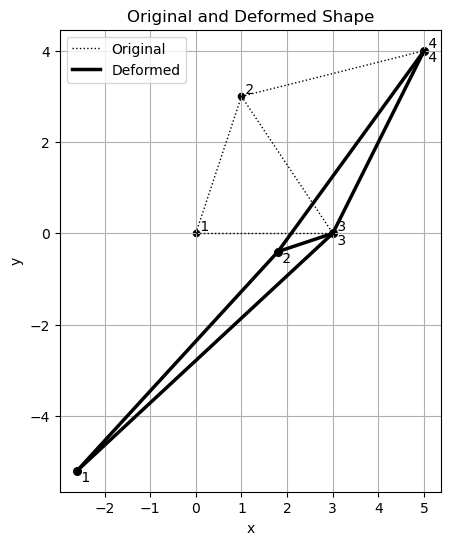

In [10]:
_,_ = plot_original_and_deformed_shape_2d(elements, nodes, nodes_new)

In [11]:
x, y, x_f, y_f = build_coordinate_vectors(nodes_new, free_nodes, fixed_nodes)
u, v = build_branch_coordinate_differences(C, C_f, x, y, x_f, y_f)

l = np.sqrt(u**2 + v**2).ravel()
print("Branch lengths, l:")
print(l)

s = np.asarray(q).ravel() * l
print("\nBranch forces, s = q*l:")
print(s)

Branch lengths, l:
[7.642  6.5115 1.2649 5.4406 4.4721]

Branch forces, s = q*l:
[7.642  3.2558 0.6325 2.7203 4.4721]


### Interpretation of the Result

A few important observations:

- the method did **not** require us to guess the final shape and iterate to equilibrium
- the prescribed force densities controlled the relative stiffness of the branches in a geometric sense
- once the coordinates are known, member forces follow from
  $$
  s_i = q_i l_i
  $$

This also shows one limitation of the classical (linear) force density method:

If the chosen force densities are not physically meaningful for the structure we actually want, the resulting shape may not be useful.

Force density is elegant, but it places a lot of modeling importance on the selection of $q_i$.

## Part 6 - New Equilibrium Shapes from Changing the Force Density

In [12]:
# New Force Density
q_2 = np.array([3.0, 3.0, 2, 2.5, 0.5])

# Same Applied Loading
nodes_loads_2 = {
    1: (-10.0, -10.0),
    2: (0.0, 0.0),
    3: (0.0, 0.0),
    4: (0.0, 0.0),
}

In [13]:
def create_node_force_vectors(nodes_loads, free_nodes):

    p_x = np.array([nodes_loads[node][0] for node in free_nodes], dtype=float).reshape(-1, 1)
    p_y = np.array([nodes_loads[node][1] for node in free_nodes], dtype=float).reshape(-1, 1)

    return p_x, p_y

p_x, p_y = create_node_force_vectors(nodes_loads_2, free_nodes)

print("\nNode force vectors (p_x, p_y) for free nodes:")
print("p_x:\n", p_x) 
print("p_y:\n", p_y)



Node force vectors (p_x, p_y) for free nodes:
p_x:
 [[-10.]
 [  0.]]
p_y:
 [[-10.]
 [  0.]]


In [14]:
D = C.T @ np.diag(q_2) @ C
D_f = C.T @ np.diag(q_2) @ C_f

x = np.linalg.solve(D, p_x - D_f @ x_f)
y = np.linalg.solve(D, p_y - D_f @ y_f)

print("\nComputed free-node displacements (x, y):")
print("x:\n", x)
print("y:\n", y)


Computed free-node displacements (x, y):
x:
 [[1.3333]
 [3.    ]]
y:
 [[-1.25  ]
 [ 0.8333]]


In [15]:
def update_node_coordinates(nodes, free_nodes, x, y):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()

    nodes_new = dict(nodes)

    for i, node in enumerate(free_nodes):
        nodes_new[node] = (float(x[i]), float(y[i]))

    return nodes_new

nodes_new_2 = update_node_coordinates(nodes, free_nodes, x, y)

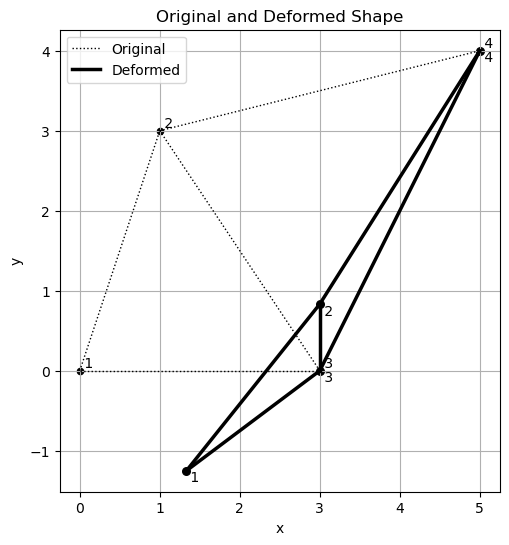

In [16]:
_,_ = plot_original_and_deformed_shape_2d(elements, nodes, nodes_new_2)

In [17]:
x, y, x_f, y_f = build_coordinate_vectors(nodes_new_2, free_nodes, fixed_nodes)
u, v = build_branch_coordinate_differences(C, C_f, x, y, x_f, y_f)

l = np.sqrt(u**2 + v**2).ravel()
print("Branch lengths, l:")
print(l)

s = np.asarray(q).ravel() * l
print("\nBranch forces, s = q*l:")
print(s)

Branch lengths, l:
[2.0833 2.668  0.8333 3.7454 4.4721]

Branch forces, s = q*l:
[2.0833 1.334  0.4167 1.8727 4.4721]


### Incrementing a Force Density Term

One drawback of the force density method is that it is not easy to predict the final shape directly from the prescribed force densities.

So in practice, we often **search the design space** by varying one or more $q_i$ values and recomputing the equilibrium geometry.

A useful rule of thumb is:

- larger $q_i$ $\rightarrow$ shorter member
- smaller $q_i$ $\rightarrow$ longer member

More importantly, the final shape depends mainly on the **relative force densities** between members.

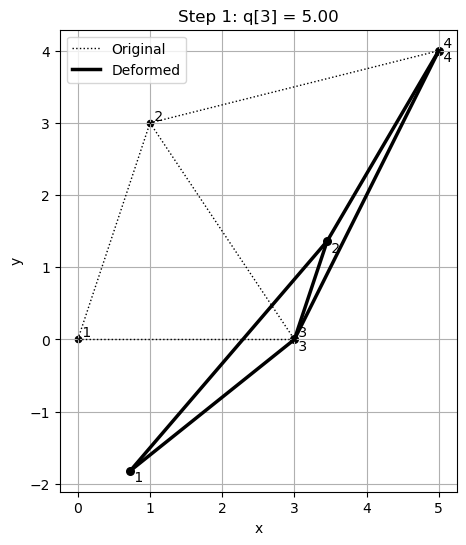

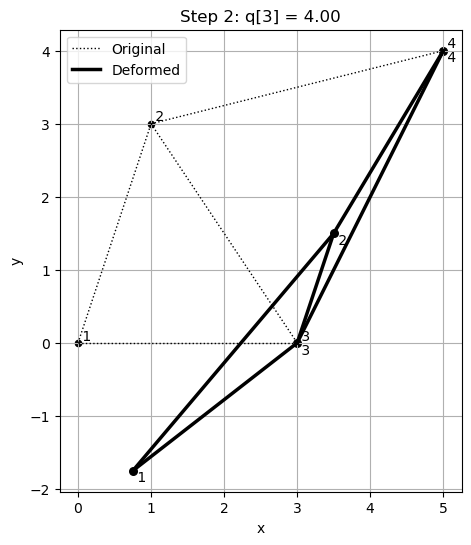

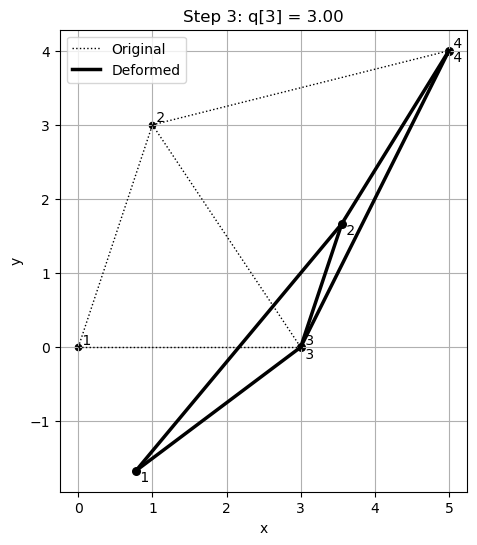

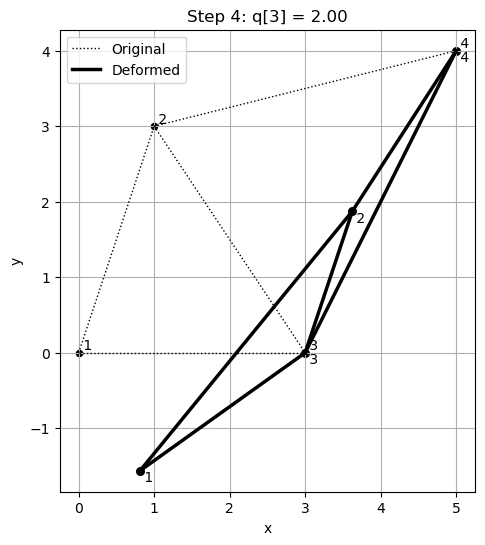

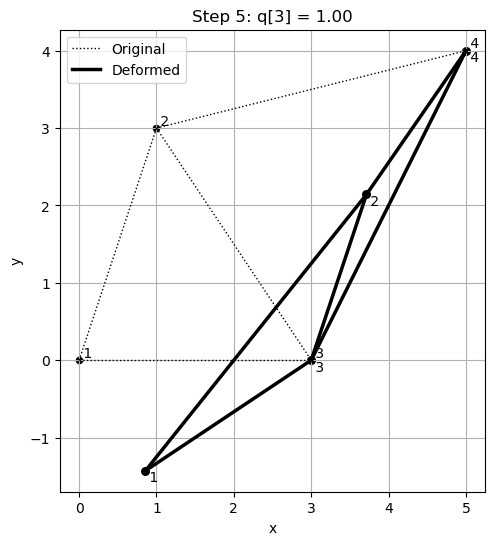

In [18]:
q_2 = np.array([2, 2, 5, 5, 5], dtype=float)

index_to_update = 2   # zero-based index
increment = -1
n_steps = 5

for step in range(n_steps):
    q_step = q_2.copy()
    q_step[index_to_update] += step * increment

    D = C.T @ np.diag(q_step) @ C
    D_f = C.T @ np.diag(q_step) @ C_f

    x = np.linalg.solve(D, p_x - D_f @ x_f)
    y = np.linalg.solve(D, p_y - D_f @ y_f)

    nodes_new_2 = update_node_coordinates(nodes, free_nodes, x, y)

    fig, ax = plot_original_and_deformed_shape_2d(
        elements,
        nodes,
        nodes_new_2,
        title=f"Step {step + 1}: q[{index_to_update + 1}] = {q_step[index_to_update]:.2f}",
    )
    plt.show()

## 

See `FD_solver.ipynb` in the `../../Code/L12` folder for a full Google Colab-compatible implementation of a standard linear force density solver.

## Part 7 - 3D Example (Next Lecture)

<figure style="margin:0; text-align:center; display:flex; flex-direction:column;">
    <img src="assets/L2_3Dexample1.png" style="width:100%; height:auto;">
</figure>

<figure style="margin:0; text-align:center; display:flex; flex-direction:column;">
    <img src="assets/L2_3Dexample2.png" style="width:75%; height:auto;">
</figure>

<figure style="margin:0; text-align:center; display:flex; flex-direction:column;">
    <img src="assets/L2_3Dexample3.png" style="width:100%; height:auto;">
</figure>

## Wrap-Up

In this lecture, we:

- placed the force density method within the broader form-finding framework discussed by Veenendaal and Block
- introduced Schek's force density method as a network-based form-finding approach
- defined the branch-node matrix and its partition into free-node and fixed-node parts
- derived the linear coordinate equations using force densities and branch equilibrium
- worked through a simple planar example and recovered the final geometry, branch lengths, and branch forces

Main takeaway: Once the connectivity, supports, loads, and force densities are prescribed, the force density method finds the equilibrium geometry through a linear solve.